# Skills analysis

Reads four CSVs describing a 30-person engineering organisation — who works here,
what they are good at, what they are certified in, and what they have been learning —
and answers three questions:

1. Which skills does the business depend on that rest on too few people?
2. Which certifications lapse next?
3. Is learning time going where the gaps are?

It writes the tables to Databricks when run there, saves three charts, and generates
[`Deliverables/FINDINGS.md`](../Deliverables/FINDINGS.md).

**Requirements:** `pandas` and `matplotlib`. Runs as-is on a laptop; on Databricks it
also persists the tables to Unity Catalog.

## 1 · Setup

In [1]:
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

# Code/ holds this notebook; Data/ and Deliverables/ sit beside it at the root.
def repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Data" / "employees.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find Data/employees.csv above " + str(start))

ROOT = repo_root(Path.cwd().resolve())
DATA, DELIVERABLES = ROOT / "Data", ROOT / "Deliverables"
CHARTS = DELIVERABLES / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

# Pinned, so every figure in the report is reproducible rather than drifting
# with the wall clock.
AS_OF = date(2026, 9, 22)

# Proficiency is a 1-5 scale. Someone at 4+ can carry the skill without help,
# which is what "does this rest on one person" has to mean to be useful.
DEEP = 4
EXPIRY_WARNING_DAYS = 90

# The one judgement call in this notebook, and the first thing to argue with:
# which skills the business actually depends on. Everything else is derived.
CRITICAL_SKILLS = {
    "BGP / Routing", "Cloud Security", "Kubernetes", "Observability",
    "Python", "Terraform", "Zero Trust",
}

print(f"Repository : {ROOT}")
print(f"As of      : {AS_OF}")

Repository : /home/user/YMEHIO78
As of      : 2026-09-22


## 2 · Load the data

Four tidy CSVs, one row per fact. No cleaning required.

In [2]:
employees = pd.read_csv(DATA / "employees.csv", parse_dates=["hire_date"])
skills = pd.read_csv(DATA / "skills.csv", parse_dates=["last_assessed"])
certifications = pd.read_csv(DATA / "certifications.csv", parse_dates=["expires_on"])
learning = pd.read_csv(DATA / "learning.csv", parse_dates=["completed_on"])

for name, frame in [("employees", employees), ("skills", skills),
                    ("certifications", certifications), ("learning", learning)]:
    print(f"{name:16s} {len(frame):3d} rows   {', '.join(frame.columns)}")

skills.head()

employees         30 rows   employee_id, name, team, role, hire_date
skills            90 rows   employee_id, skill, proficiency, last_assessed
certifications    22 rows   employee_id, certification, cost_usd, expires_on
learning          40 rows   employee_id, course, skill, hours, completed_on


,employee_id,skill,proficiency,last_assessed
0,1001,BGP / Routing,5,2026-04-13
1,1001,Network Automation,4,2026-02-06
2,1001,Python,4,2025-11-24
3,1002,BGP / Routing,4,2026-07-22
4,1002,Python,3,2026-04-25


## 3 · Prepare

Two derived things: a per-skill coverage table, and days-to-expiry on each
certification. Everything downstream reads these.

In [3]:
# One row per skill: how many people have it, how many could carry it alone,
# and how much learning time went into it over the last year.
coverage = (
    skills.assign(is_deep=skills["proficiency"] >= DEEP)
    .groupby("skill")
    .agg(
        people=("employee_id", "nunique"),
        deep_practitioners=("is_deep", "sum"),
        avg_proficiency=("proficiency", "mean"),
    )
    .reset_index()
)
coverage["is_critical"] = coverage["skill"].isin(CRITICAL_SKILLS)
coverage["learning_hours"] = (
    coverage["skill"].map(learning.groupby("skill")["hours"].sum()).fillna(0).astype(int)
)
coverage["avg_proficiency"] = coverage["avg_proficiency"].round(2)

# Name the people a skill rests on - a bus-factor number nobody can act on.
deep_by_skill = (
    skills[skills["proficiency"] >= DEEP]
    .merge(employees[["employee_id", "name"]], on="employee_id")
    .groupby("skill")["name"]
    .apply(lambda names: ", ".join(sorted(names)))
)
coverage["held_by"] = coverage["skill"].map(deep_by_skill).fillna("")

# Certifications: how long until each one lapses.
certifications["days_to_expiry"] = [
    (d.date() - AS_OF).days for d in certifications["expires_on"]
]


def risk_band(days: int) -> str:
    if days < 0:
        return "Expired"
    if days <= EXPIRY_WARNING_DAYS:
        return f"Expiring in {EXPIRY_WARNING_DAYS} days or less"
    if days <= 365:
        return "Expiring within 12 months"
    return "Current"


certifications["risk_band"] = certifications["days_to_expiry"].map(risk_band)
certifications = certifications.merge(
    employees[["employee_id", "name", "team"]], on="employee_id"
)

coverage.sort_values(["is_critical", "deep_practitioners"], ascending=[False, True])

,skill,people,deep_practitioners,avg_proficiency,is_critical,learning_hours,held_by
5,Observability,16,0,2.50,True,0,
3,Kubernetes,6,1,3.00,True,6,Rohan Varma
9,Zero Trust,4,1,3.00,True,4,Greta Ahlberg
1,Cloud Security,6,2,3.17,True,12,"Greta Ahlberg, Nathan Ifeanyi"
8,Terraform,6,2,3.00,True,18,"Elena Pavlova, Rohan Varma"
0,BGP / Routing,6,3,3.33,True,15,"Daniel Osei, Maya Restrepo, Priya Raman"
6,Python,19,7,3.16,True,120,"Elena Pavlova, Henrik Sole, Lucia Ferrari, Mar..."
2,Incident Response,8,4,3.50,False,46,"Isabel Ortiz, Jonas Weber, Leila Farsi, Nathan..."
4,Network Automation,8,4,3.25,False,40,"Felix Andersen, Henrik Sole, Maya Restrepo, Pr..."
7,SQL,11,6,3.55,False,78,"Hannah Brecht, Isabel Ortiz, Kofi Mensah, Luci..."


## 4 · Store in Databricks

Runs only on Databricks. Locally this cell prints a note and the rest of the
notebook carries on from the CSVs.

In [4]:
TABLES = {
    "employees": employees,
    "skills": skills,
    "certifications": certifications,
    "learning": learning,
    "skill_coverage": coverage,
}

try:
    spark  # defined only inside Databricks
except NameError:
    print("Not running on Databricks - skipping the table writes.")
    print("Everything below runs from the CSVs, so the analysis is unaffected.")
else:
    CATALOG, SCHEMA = "skills_analysis", "main"
    spark.sql(f"CREATE CATALOG IF NOT EXISTS {CATALOG}")
    spark.sql(f"CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}")
    for table_name, frame in TABLES.items():
        (
            spark.createDataFrame(frame)
            .write.mode("overwrite")
            .option("overwriteSchema", "true")
            .saveAsTable(f"{CATALOG}.{SCHEMA}.{table_name}")
        )
        print(f"wrote {CATALOG}.{SCHEMA}.{table_name:16s} {len(frame):3d} rows")

Not running on Databricks - skipping the table writes.
Everything below runs from the CSVs, so the analysis is unaffected.


## 5 · Chart styling

One helper, used by all three charts, so they read as one set.

In [5]:
from matplotlib.patches import Patch

# A validated palette. One hue carries magnitude; the status red means "at risk"
# and is never used for a series. Every coloured mark also carries a text label,
# so nothing depends on colour alone.
LIGHT = dict(name="light", surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e",
             muted="#898781", grid="#e1e0d9", baseline="#c3c2b7",
             series="#2a78d6", critical="#d03b3b", warning="#fab219")
DARK = dict(name="dark", surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7",
            muted="#898781", grid="#2c2c2a", baseline="#383835",
            series="#3987e5", critical="#d03b3b", warning="#fab219")

plt.rcParams["font.family"] = "DejaVu Sans"


def new_axes(theme, figsize):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(theme["surface"])
    ax.set_facecolor(theme["surface"])
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(theme["baseline"])
    ax.tick_params(colors=theme["muted"], labelsize=9, length=0)
    for label in ax.get_yticklabels() + ax.get_xticklabels():
        label.set_color(theme["ink2"])
    return fig, ax


def titled(ax, theme, title, subtitle=""):
    # The subtitle is offset in points, not axes fractions: a fraction of a tall
    # axes is a long way up, which is how a subtitle ends up on top of its title.
    ax.set_title(title, color=theme["ink"], fontsize=12.5, fontweight="bold",
                 loc="left", pad=30 if subtitle else 12)
    if subtitle:
        ax.annotate(subtitle, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 9), textcoords="offset points",
                    color=theme["muted"], fontsize=9.2, va="bottom", ha="left")


def legend(ax, theme, handles, loc="lower right"):
    box = ax.legend(handles=handles, loc=loc, frameon=False, fontsize=8.8)
    for text in box.get_texts():
        text.set_color(theme["ink2"])


def render(draw, slug):
    """Draw once per theme, save both, show the light one inline."""
    saved = {}
    for theme in (LIGHT, DARK):
        fig = draw(theme)
        path = CHARTS / f"{slug}-{theme['name']}.png"
        fig.savefig(path, dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
        plt.close(fig)
        saved[theme["name"]] = path
    display(Image(filename=str(saved["light"])))
    return saved

## 6 · Finding 1 — where capability is concentrated

A skill is covered when more than one person can carry it alone.

3 of 7 critical skills rest on one person or nobody

  Observability    16 people have it, 0 at level 4+  (nobody)
  Kubernetes        6 people have it, 1 at level 4+  (Rohan Varma)
  Zero Trust        4 people have it, 1 at level 4+  (Greta Ahlberg)


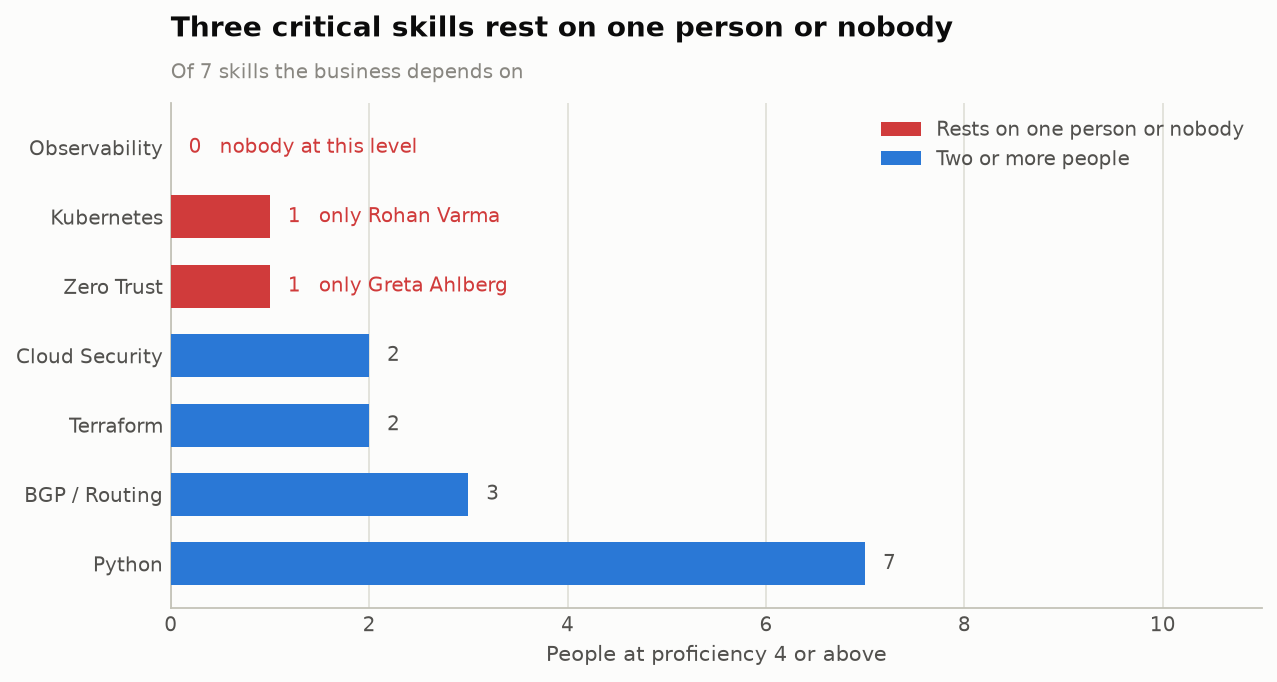

In [6]:
critical = coverage[coverage["is_critical"]].sort_values(
    ["deep_practitioners", "people"], ascending=[True, False]
)
exposed = critical[critical["deep_practitioners"] <= 1]

print(f"{len(exposed)} of {len(critical)} critical skills rest on one person or nobody\n")
for _, row in exposed.iterrows():
    holder = row["held_by"] or "nobody"
    print(f"  {row['skill']:16s} {row['people']:2d} people have it, "
          f"{row['deep_practitioners']} at level {DEEP}+  ({holder})")


def draw_skill_depth(theme):
    fig, ax = new_axes(theme, (8.8, 4.1))
    colours = [theme["critical"] if n <= 1 else theme["series"]
               for n in critical["deep_practitioners"]]
    bars = ax.barh(critical["skill"], critical["deep_practitioners"],
                   color=colours, height=0.62, zorder=3)
    ax.xaxis.grid(True, color=theme["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlim(0, int(critical["deep_practitioners"].max()) + 4)
    ax.invert_yaxis()  # the exposed skills belong at the top, not buried
    ax.set_xlabel(f"People at proficiency {DEEP} or above", color=theme["ink2"], fontsize=9.5)
    titled(ax, theme, "Three critical skills rest on one person or nobody",
           f"Of {len(critical)} skills the business depends on")

    for bar, (_, row) in zip(bars, critical.iterrows()):
        count = int(row["deep_practitioners"])
        if count == 0:
            note, colour = "0   nobody at this level", theme["critical"]
        elif count == 1:
            note, colour = f"1   only {row['held_by']}", theme["critical"]
        else:
            note, colour = str(count), theme["ink2"]
        ax.text(bar.get_width() + 0.18, bar.get_y() + bar.get_height() / 2,
                note, va="center", fontsize=9, color=colour)

    # Top-right: the only corner with no bar and no value label in it.
    legend(ax, theme, [
        Patch(facecolor=theme["critical"], label="Rests on one person or nobody"),
        Patch(facecolor=theme["series"], label="Two or more people"),
    ], loc="upper right")
    return fig


chart_1 = render(draw_skill_depth, "01-critical-skill-depth")

## 7 · Finding 2 — what lapses next

6 certifications are expired or lapse within 90 days
$3,694 of the $10,657 certification budget

risk_band
Current                        11
Expiring within 12 months       5
Expiring in 90 days or less     4
Expired                         2


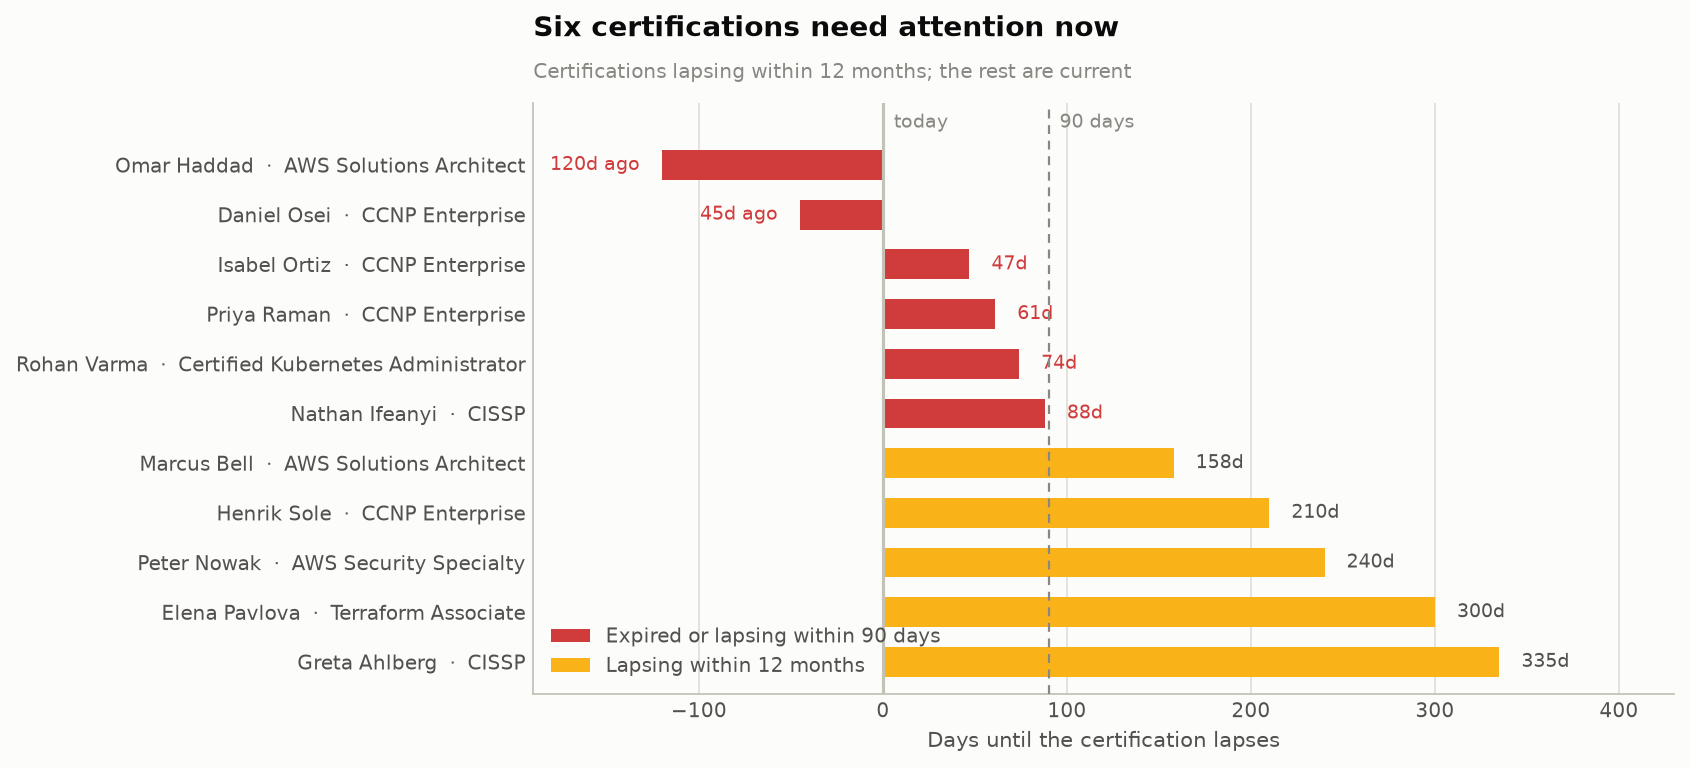

In [7]:
at_risk = certifications[certifications["days_to_expiry"] <= EXPIRY_WARNING_DAYS]
soon = certifications[certifications["days_to_expiry"] <= 365].sort_values("days_to_expiry")

print(f"{len(at_risk)} certifications are expired or lapse within {EXPIRY_WARNING_DAYS} days")
print(f"${at_risk['cost_usd'].sum():,} of the ${certifications['cost_usd'].sum():,} "
      f"certification budget\n")
print(certifications["risk_band"].value_counts().to_string())


def draw_cert_expiry(theme):
    fig, ax = new_axes(theme, (9.2, 4.8))
    colours = [theme["critical"] if days <= EXPIRY_WARNING_DAYS else theme["warning"]
               for days in soon["days_to_expiry"]]
    labels = [f"{row['name']}  ·  {row['certification']}" for _, row in soon.iterrows()]
    bars = ax.barh(labels, soon["days_to_expiry"], color=colours, height=0.6, zorder=3)
    ax.invert_yaxis()
    ax.xaxis.grid(True, color=theme["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.axvline(0, color=theme["baseline"], linewidth=1.4, zorder=4)
    ax.axvline(EXPIRY_WARNING_DAYS, color=theme["muted"], linewidth=1,
               linestyle=(0, (4, 3)), zorder=4)
    ax.set_xlabel("Days until the certification lapses", color=theme["ink2"], fontsize=9.5)
    ax.set_xlim(soon["days_to_expiry"].min() - 70, 430)
    titled(ax, theme, "Six certifications need attention now",
           "Certifications lapsing within 12 months; the rest are current")

    for bar, (_, row) in zip(bars, soon.iterrows()):
        days = int(row["days_to_expiry"])
        text = f"{abs(days)}d ago" if days < 0 else f"{days}d"
        offset = -12 if days < 0 else 12
        ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2, text,
                va="center", ha="right" if days < 0 else "left", fontsize=8.6,
                color=theme["critical"] if days <= EXPIRY_WARNING_DAYS else theme["ink2"])

    ax.set_ylim(len(soon) - 0.35, -1.25)  # headroom for the two axis notes
    ax.text(6, -0.85, "today", color=theme["muted"], fontsize=8.4, va="center")
    ax.text(EXPIRY_WARNING_DAYS + 6, -0.85, f"{EXPIRY_WARNING_DAYS} days",
            color=theme["muted"], fontsize=8.4, va="center")
    legend(ax, theme, [
        Patch(facecolor=theme["critical"], label=f"Expired or lapsing within {EXPIRY_WARNING_DAYS} days"),
        Patch(facecolor=theme["warning"], label="Lapsing within 12 months"),
    ], loc="lower left")  # the right-hand side is where the longest bars end
    return fig


chart_2 = render(draw_cert_expiry, "02-certification-expiry")

## 8 · Finding 3 — is learning going where the gaps are?

Coverage against learning hours, one point per skill. If investment tracked risk,
the points would slope down to the right. They slope up.

339 learning hours in the last 12 months
10 of them (2.9%) went to the 3 skills that rest on one person or nobody
Python alone took 120 hours and already has 7 people at level 4+


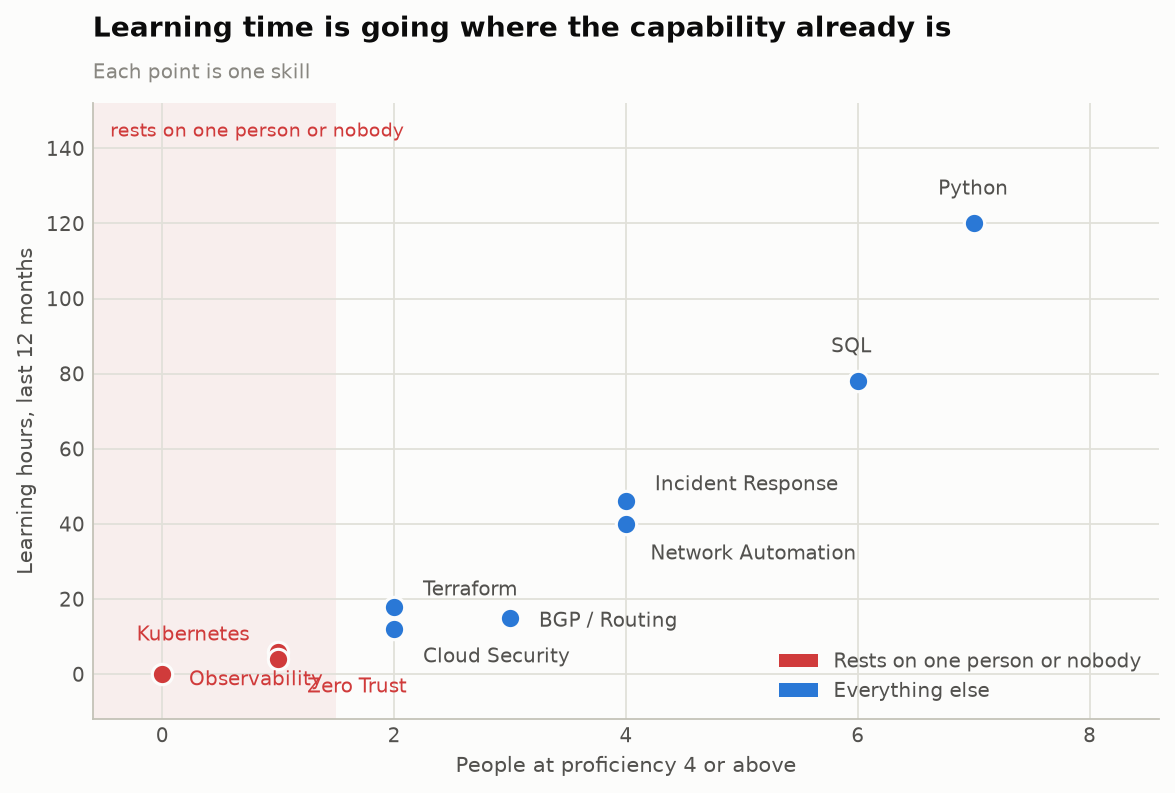

In [8]:
coverage["is_exposed"] = coverage["is_critical"] & (coverage["deep_practitioners"] <= 1)
total_hours = int(coverage["learning_hours"].sum())
exposed_hours = int(coverage.loc[coverage["is_exposed"], "learning_hours"].sum())
python_row = coverage[coverage["skill"] == "Python"].iloc[0]

print(f"{total_hours} learning hours in the last 12 months")
print(f"{exposed_hours} of them ({exposed_hours / total_hours:.1%}) went to the "
      f"{int(coverage['is_exposed'].sum())} skills that rest on one person or nobody")
print(f"Python alone took {int(python_row['learning_hours'])} hours and already has "
      f"{int(python_row['deep_practitioners'])} people at level {DEEP}+")

# Nudged so the labels do not collide; the points themselves are unmoved.
# Kubernetes and Zero Trust sit two hours apart on a 145-hour axis, so their
# labels go in opposite directions or they land on top of each other.
LABEL_OFFSETS = {
    "Observability": (12, -5), "Kubernetes": (-13, 5, "right"), "Zero Trust": (13, -15),
    "Cloud Security": (13, -15), "Terraform": (13, 5), "BGP / Routing": (13, -4),
    "Incident Response": (13, 5), "Network Automation": (11, -16),
    "SQL": (-12, 13), "Python": (-16, 13),
}


def draw_learning_vs_gap(theme):
    fig, ax = new_axes(theme, (8.6, 5.0))
    ax.grid(True, color=theme["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    # Band the exposed zone instead of pointing an arrow into a crowded corner.
    ax.axvspan(-0.6, 1.5, color=theme["critical"], alpha=0.07, zorder=0, linewidth=0)

    for is_exposed, group in coverage.groupby("is_exposed"):
        ax.scatter(group["deep_practitioners"], group["learning_hours"],
                   s=84, zorder=3, linewidth=1.4, edgecolor=theme["surface"],
                   color=theme["critical"] if is_exposed else theme["series"],
                   label=("Rests on one person or nobody" if is_exposed
                          else "Everything else"))

    for _, row in coverage.iterrows():
        offset = LABEL_OFFSETS.get(row["skill"], (12, 4))
        dx, dy, *rest = offset
        ax.annotate(row["skill"],
                    (row["deep_practitioners"], row["learning_hours"]),
                    textcoords="offset points", xytext=(dx, dy),
                    ha=rest[0] if rest else "left", fontsize=8.8,
                    color=theme["critical"] if row["is_exposed"] else theme["ink2"])

    ax.set_xlabel(f"People at proficiency {DEEP} or above", color=theme["ink2"], fontsize=9.5)
    ax.set_ylabel("Learning hours, last 12 months", color=theme["ink2"], fontsize=9.5)
    ax.set_xlim(-0.6, 8.6)
    ax.set_ylim(-12, 152)
    titled(ax, theme, "Learning time is going where the capability already is",
           "Each point is one skill")
    ax.text(-0.45, 147, "rests on one person or nobody", color=theme["critical"],
            fontsize=8.6, va="top", ha="left")
    legend(ax, theme, [
        Patch(facecolor=theme["critical"], label="Rests on one person or nobody"),
        Patch(facecolor=theme["series"], label="Everything else"),
    ], loc="lower right")
    return fig


chart_3 = render(draw_learning_vs_gap, "03-learning-vs-coverage")

## 9 · Write the report

In [9]:
def picture(slug, alt):
    """GitHub swaps the image with the reader\'s colour scheme."""
    return (
        "<picture>\n"
        f'  <source media="(prefers-color-scheme: dark)" srcset="charts/{slug}-dark.png">\n'
        f'  <img alt="{alt}" src="charts/{slug}-light.png">\n'
        "</picture>"
    )


exposed_names = ", ".join(exposed["skill"])
observability = coverage[coverage["skill"] == "Observability"].iloc[0]
kubernetes = coverage[coverage["skill"] == "Kubernetes"].iloc[0]
zero_trust = coverage[coverage["skill"] == "Zero Trust"].iloc[0]
expired = certifications[certifications["days_to_expiry"] < 0]
lapsing = at_risk[at_risk["days_to_expiry"] >= 0]

report = f"""# Skills analysis — findings

**As of {AS_OF:%d %B %Y}** · {len(employees)} people across {employees["team"].nunique()} teams ·
{skills["skill"].nunique()} tracked skills · {len(certifications)} certifications ·
{total_hours} learning hours in the last 12 months

Three things in this data are worth acting on. All three point the same way: the
organisation is investing in capability it already has, while the capability it
depends on sits with one person at a time.

---

## Finding 1 — {len(exposed)} of {len(critical)} critical skills rest on one person or nobody

{picture("01-critical-skill-depth", "Bar chart of people at proficiency 4+ for each critical skill")}

A skill is only genuinely covered when more than one person can carry it without
help. On that test, three of the seven skills the business depends on are a single
unplanned absence away from a gap:

| Skill | People who have it | At level {DEEP}+ | Who it rests on |
|---|---:|---:|---|
| Observability | {int(observability["people"])} | **0** | nobody |
| Kubernetes | {int(kubernetes["people"])} | **1** | {kubernetes["held_by"]} |
| Zero Trust | {int(zero_trust["people"])} | **1** | {zero_trust["held_by"]} |

**Observability is the one to look at twice.** {int(observability["people"])} of
{len(employees)} people have it — the most widely held skill after Python — and not
one of them is above intermediate. Breadth has been mistaken for depth. That is also
what makes it the cheapest gap to close: the base is already there.

---

## Finding 2 — {len(at_risk)} certifications are expired or lapse within {EXPIRY_WARNING_DAYS} days

{picture("02-certification-expiry", "Bar chart of days until each certification lapses")}

{len(expired)} have already lapsed and {len(lapsing)} lapse inside
{EXPIRY_WARNING_DAYS} days — **${at_risk["cost_usd"].sum():,} of the
${certifications["cost_usd"].sum():,} certification budget**. Renewals need exam
booking and study time, so the cost of finding out late is the whole problem:

| Worker | Certification | Status |
|---|---|---|
""" + "\n".join(
    f"| {row['name']} | {row['certification']} | "
    f"{'Expired ' + str(abs(row['days_to_expiry'])) + ' days ago' if row['days_to_expiry'] < 0 else 'Lapses in ' + str(row['days_to_expiry']) + ' days'} |"
    for _, row in at_risk.sort_values("days_to_expiry").iterrows()
) + f"""

---

## Finding 3 — learning time is going where the capability already is

{picture("03-learning-vs-coverage", "Scatter plot of learning hours against number of deep practitioners per skill")}

Of {total_hours} learning hours in the last twelve months,
**{exposed_hours} ({exposed_hours / total_hours:.0%}) went to the three skills that rest
on one person or nobody.** Python took {int(python_row["learning_hours"])} hours — the
largest single share — and already has {int(python_row["deep_practitioners"])} people at
level {DEEP}+. Observability received none at all.

This is not a motivation problem. People are learning; the hours are simply
uncorrelated with where the risk is, because nothing connects the two.

---

## What to do about it

### 1. Give Kubernetes and Zero Trust a second owner this quarter

Name a backup for each, and give them time with
{kubernetes["held_by"]} and {zero_trust["held_by"]} rather than a course.
Two people, two skills, one quarter — this is the smallest change that removes the
sharpest risk.

### 2. Build Observability depth from the {int(observability["people"])} people who already have the basics

No hiring required. Pick three or four of them, set a target of level {DEEP} by the end
of the next quarter, and give it real hours. A skill with a wide shallow base is the
easiest kind of gap to close.

### 3. Point next year's learning budget at the gaps, not the strengths

Move roughly a third of the {total_hours} hours toward the exposed skills. The current
split is close to the opposite of what the coverage data argues for, and no one has to
learn less — Python is simply already covered.

---

## Method and limits

- **Proficiency is a 1–5 scale.** Level {DEEP}+ means "can carry the skill without
  help", which is what a bus-factor number has to mean to be worth anything.
- **Criticality is a judgement, not a measurement.** The seven critical skills are
  listed at the top of `Code/skills_analysis.ipynb`. It drives Finding 1, so it is the
  first assumption to challenge.
- **{len(employees)} people.** Percentages move about three points per person — read
  the counts, not the decimals.
- **The as-of date is pinned** to {AS_OF}, so every figure here is reproducible rather
  than drifting with the calendar.
- Every number and chart on this page is generated by the notebook. Re-running it
  overwrites this file, so it cannot drift from the data.
"""

path = DELIVERABLES / "FINDINGS.md"
path.write_text(report, encoding="utf-8")
print(f"Wrote {path.relative_to(ROOT)}  ({len(report):,} characters)")

Wrote Deliverables/FINDINGS.md  (4,618 characters)
